# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [50]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [51]:
df = pd.read_csv(r"C:\Users\tifaw\OneDrive\Desktop\BOOTCAMP_DATASCIENCE\REPOSITORIO_GIT\ONLINE_DS_THEBRIDGE_FATIMA_NASSIRDINE\3-Machine_Learning\2-No_Supervisado\2-PCA\Practica\data\nndb_flat.csv")

In [52]:
df.shape

(8618, 45)

In [53]:
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [55]:
df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

<Axes: >

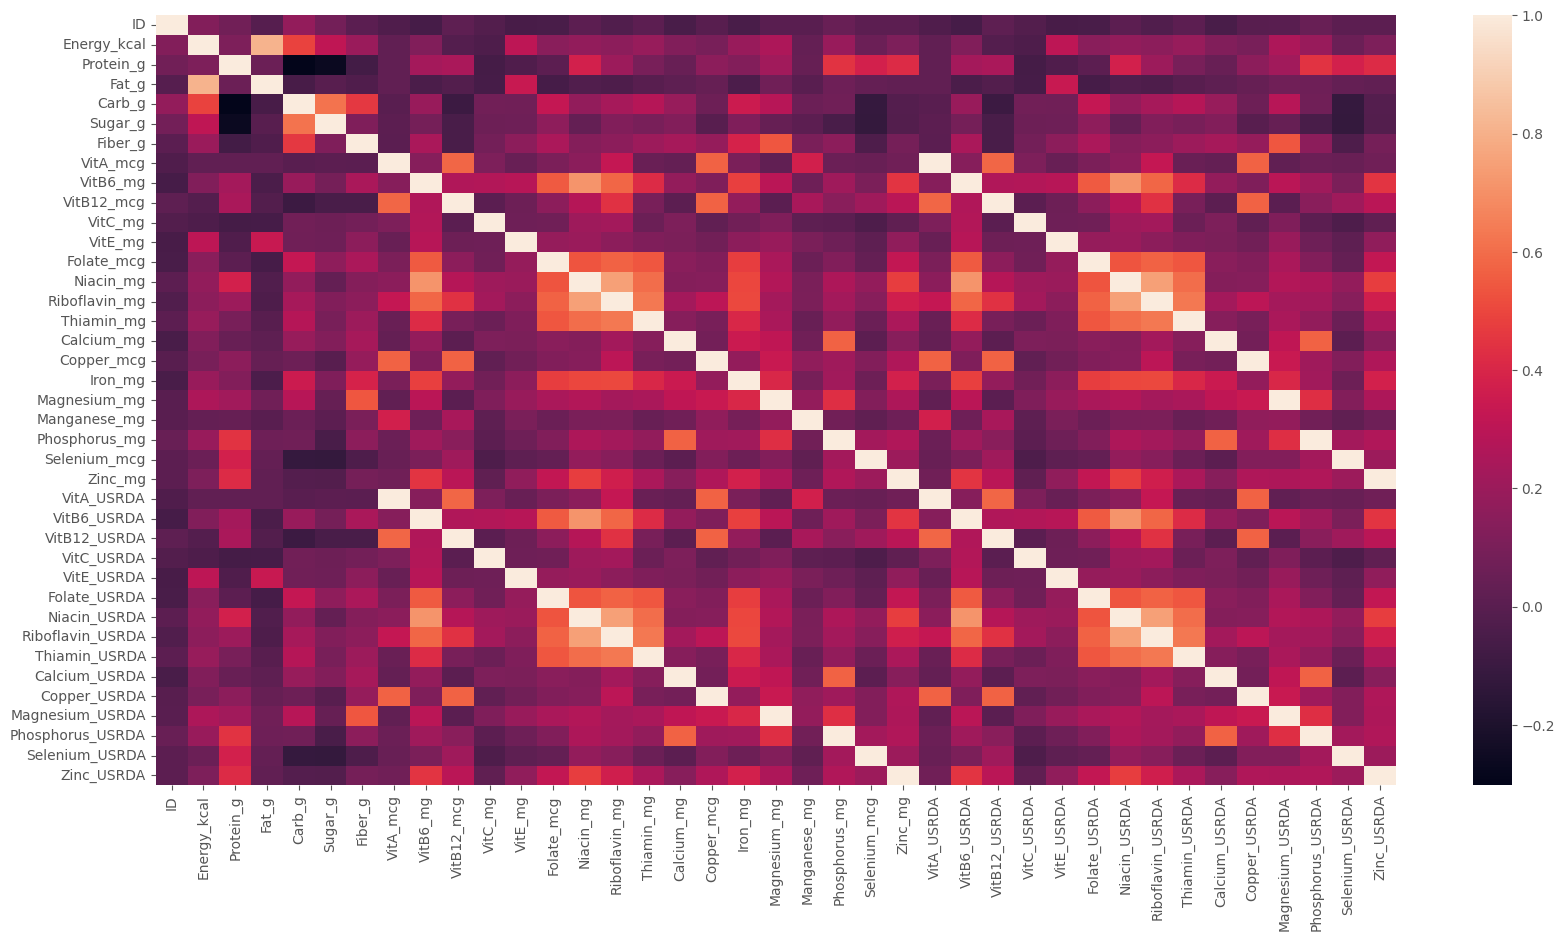

In [56]:
plt.figure(figsize=(20,10))
sns.heatmap(df.select_dtypes(include='number').corr())

In [57]:
# podemos ver en el heatmap que la mayoria de las features USRDA estan fuertemente relacionadas con las features mg.

### Variables no numéricas
Elimina las variables de texto del dataset

In [58]:
df = df.select_dtypes(include='number').drop(columns='ID')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Energy_kcal       8618 non-null   float64
 1   Protein_g         8618 non-null   float64
 2   Fat_g             8618 non-null   float64
 3   Carb_g            8618 non-null   float64
 4   Sugar_g           8618 non-null   float64
 5   Fiber_g           8618 non-null   float64
 6   VitA_mcg          8618 non-null   float64
 7   VitB6_mg          8618 non-null   float64
 8   VitB12_mcg        8618 non-null   float64
 9   VitC_mg           8618 non-null   float64
 10  VitE_mg           8618 non-null   float64
 11  Folate_mcg        8618 non-null   float64
 12  Niacin_mg         8618 non-null   float64
 13  Riboflavin_mg     8618 non-null   float64
 14  Thiamin_mg        8618 non-null   float64
 15  Calcium_mg        8618 non-null   float64
 16  Copper_mcg        8618 non-null   float64


### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [59]:
df.skew() #El método df.skew() en pandas te indica la asimetría (skewness) de la distribución de los datos en cada columna numérica
#valores mayores a 0 (+)tiene cola larga hacia la derecha
#valores menores a 0 (-) teiene uan cola larga hacia la izquierda
# valores iguales a 0(=)Distribución simétrica


#en nuestro caso hay asimetria positva en la mayoria de las variables.

Energy_kcal          1.168243
Protein_g            1.170610
Fat_g                3.306166
Carb_g               1.157211
Sugar_g              2.953324
Fiber_g              5.793241
VitA_mcg            24.090421
VitB6_mg             7.557554
VitB12_mcg          13.034297
VitC_mg             30.907462
VitE_mg             13.849434
Folate_mcg          10.327038
Niacin_mg            6.435334
Riboflavin_mg       11.312592
Thiamin_mg          17.510062
Calcium_mg          13.427978
Copper_mcg          15.943149
Iron_mg              6.839288
Magnesium_mg         5.565037
Manganese_mg        39.741772
Phosphorus_mg       18.553944
Selenium_mcg        38.207299
Zinc_mg              9.629128
VitA_USRDA          24.090421
VitB6_USRDA          7.557554
VitB12_USRDA        13.034297
VitC_USRDA          30.907462
VitE_USRDA          13.849434
Folate_USRDA        10.327038
Niacin_USRDA         6.435334
Riboflavin_USRDA    11.312592
Thiamin_USRDA       17.510062
Calcium_USRDA       13.427978
Copper_USR

In [ ]:
# relaizamos transformación logaritmica se hace con numpy

np.log1p(df)


,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.157004,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000000,0.004751,0.033711,0.018019,0.008149
1,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.122218,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000018,0.004751,0.032329,0.018019,0.004535
2,6.776507,0.246860,4.609959,0.000000,0.000000,0.0,6.734592,0.001000,0.009950,0.0,...,0.000000,0.000187,0.003839,0.000833,0.003328,0.000001,0.000000,0.004277,0.000000,0.000909
3,5.869297,3.109061,3.392493,1.205971,0.405465,0.0,5.293305,0.153579,0.797507,0.0,...,0.086178,0.061565,0.257619,0.023879,0.364643,0.000044,0.053315,0.440097,0.233994,0.216577
4,5.918894,3.188004,3.423611,1.332366,0.412110,0.0,5.680173,0.062975,0.815365,0.0,...,0.048790,0.007348,0.239017,0.011599,0.445754,0.000027,0.055570,0.497306,0.233994,0.212175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,5.723585,2.970414,3.261935,0.000000,0.000000,0.0,3.871201,0.343590,2.564949,0.0,...,0.036814,0.187516,0.136412,0.016529,0.053541,0.000111,0.133531,0.309583,0.847817,0.095310
8614,4.718499,3.069912,0.609766,1.857859,0.000000,0.0,1.098612,0.106160,1.147402,0.0,...,0.048790,0.065085,0.018293,0.009950,0.008299,0.000037,0.084429,0.475346,0.332569,0.131825
8615,5.598422,0.000000,0.000000,4.305955,4.306764,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.006231,0.045120,0.102857,0.010775,0.000022,0.023530,0.011364,0.012647,0.017125
8616,4.510860,2.839078,0.875469,1.098612,0.000000,0.0,3.433987,0.122218,0.405465,0.0,...,0.014889,0.083881,0.088293,0.008299,0.008299,0.000444,0.467023,0.328275,0.404252,0.087011


In [61]:
df = np.log1p(df) 
df.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.157004,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000000,0.004751,0.033711,0.018019,0.008149
1,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.122218,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000018,0.004751,0.032329,0.018019,0.004535
2,6.776507,0.246860,4.609959,0.000000,0.000000,0.0,6.734592,0.001000,0.009950,0.0,...,0.000000,0.000187,0.003839,0.000833,0.003328,0.000001,0.000000,0.004277,0.000000,0.000909
3,5.869297,3.109061,3.392493,1.205971,0.405465,0.0,5.293305,0.153579,0.797507,0.0,...,0.086178,0.061565,0.257619,0.023879,0.364643,0.000044,0.053315,0.440097,0.233994,0.216577
4,5.918894,3.188004,3.423611,1.332366,0.412110,0.0,5.680173,0.062975,0.815365,0.0,...,0.048790,0.007348,0.239017,0.011599,0.445754,0.000027,0.055570,0.497306,0.233994,0.212175


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [62]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df) #fit entrena al scaler para que escale los datos, y transform me aplica el scaler a mi df.
df_scaled # me sale un array de numpy porque el scaler lo convierte en un array.

array([[ 1.54041394, -1.37969871,  2.22252572, ..., -0.93528923,
        -0.72885913, -0.76704317],
       [ 1.54041394, -1.37969871,  2.22252572, ..., -0.94379087,
        -0.72885913, -0.7872277 ],
       [ 1.74566103, -1.72821981,  2.39348953, ..., -1.11633899,
        -0.81146808, -0.80748542],
       ...,
       [ 0.5368946 , -1.96180649, -1.51012816, ..., -1.07274606,
        -0.7534859 , -0.71689864],
       [-0.57899174,  0.72461786, -0.76879934, ...,  0.87655799,
         1.04189618, -0.32651035],
       [-0.59032935,  0.90996043, -1.1667887 , ...,  0.26494633,
         0.41058235, -0.32651035]], shape=(8618, 38))

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [85]:
pca = PCA(n_components= df_scaled.shape[1]) # igual al numero de columnas que teine mi df(38)

modelo_pca = pca.fit(df_scaled)
modelo_pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",38
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [83]:
#transformo el array en df
df_pca = pd.DataFrame(
    modelo_pca,
    columns=[f'PC{i+1}' for i in range(df_scaled.shape[1])]
)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38
0,-2.823468,-0.217236,-0.554212,1.156498,4.150190,-0.318799,1.901030,1.387745,-0.968875,-0.080889,...,0.031856,0.158938,-0.165095,-0.408909,-0.159737,-0.102374,0.015400,-0.016966,-0.007864,0.001497
1,-2.806940,-0.158013,-0.521869,1.154281,4.140068,-0.256935,1.907124,1.385062,-0.990099,-0.080756,...,0.020774,0.165748,-0.148164,-0.386274,-0.180601,-0.129901,0.009661,-0.014791,-0.007433,0.001124
2,-3.734573,-0.155240,-1.237491,0.746765,5.062128,0.557748,1.756942,1.127596,-1.271368,-0.167813,...,0.079279,0.127570,0.049773,-0.423478,-0.031926,-0.058380,-0.007723,-0.012862,-0.005578,0.000793
3,1.710787,-1.028797,1.160348,1.804940,0.765526,-2.923539,2.974141,-0.331643,0.167186,-0.966335,...,-0.076226,-0.074984,0.009579,0.051170,0.093108,0.056683,-0.002443,-0.002062,-0.001416,-0.017975
4,1.464149,-0.870991,1.554679,2.279470,0.967722,-3.293454,3.664296,-0.741080,0.121179,-1.186535,...,-0.030441,-0.096291,0.015665,0.111672,-0.201554,0.150728,0.023586,-0.006474,-0.020809,-0.018787


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.31615728 0.4538689  0.53390631 0.59725482 0.65299957 0.69636257
 0.737973   0.76855396 0.79313914 0.81687444 0.83789043 0.85663579
 0.87197687 0.88663969 0.90013387 0.91289942 0.92479768 0.93502549
 0.94407387 0.95185498 0.95891485 0.96552223 0.97141814 0.97668562
 0.98103698 0.98504798 0.98884721 0.99132773 0.99332472 0.99512449
 0.99687703 0.99845598 0.99929733 0.9998422  0.99994765 0.99998485
 0.99999534 1.        ]


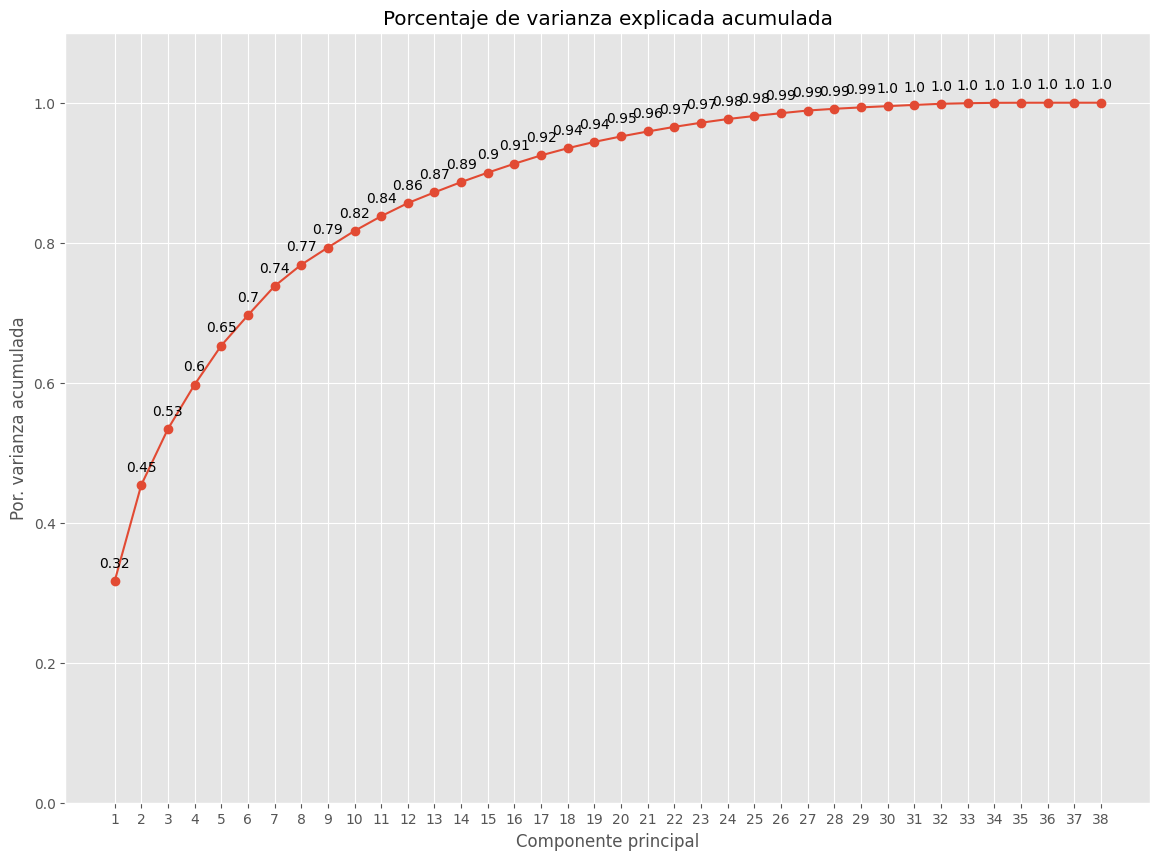

In [88]:
# Porcentaje de varianza explicada acumulada
# ==============================================================================
prop_varianza_acum = modelo_pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))
ax.plot(
    np.arange(len(df.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(df.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

In [ ]:
# Seleccioanriamos los componentes del 1 al 6 porque la varianza acumulada de los 6 componentes forma el 70%.

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [ ]:
nuevo_pca =PCA(n_components= 6) # los componentes

modelo_2_pca = nuevo_pca.fit_transform(df_scaled) # transform me o convierte en un array de numpy.
modelo_2_pca


array([[-2.82346763, -0.21723553, -0.55421178,  1.15649843,  4.15019034,
        -0.31879894],
       [-2.80693955, -0.15801341, -0.52186892,  1.15428131,  4.14006813,
        -0.25693499],
       [-3.73457302, -0.15523959, -1.23749091,  0.74676544,  5.06212825,
         0.55774822],
       ...,
       [-3.56956422,  1.56608882, -0.16293237, -1.55753547, -0.16261907,
         0.80098955],
       [ 1.36041808, -0.32787152,  2.45745143,  2.49849079,  1.62477893,
        -0.18799805],
       [-0.00545541, -1.32758045,  0.41426972,  1.81478457, -0.52003108,
        -0.83349401]], shape=(8618, 6))

In [95]:
#transformo el array en df
df_6_comp = pd.DataFrame(
    modelo_2_pca,
    columns=[f'PC{i+1}' for i in range(modelo_2_pca.shape[1])]
)
df_6_comp.head()


,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.823468,-0.217236,-0.554212,1.156498,4.150190,-0.318799
1,-2.806940,-0.158013,-0.521869,1.154281,4.140068,-0.256935
2,-3.734573,-0.155240,-1.237491,0.746765,5.062128,0.557748
3,1.710787,-1.028797,1.160348,1.804940,0.765526,-2.923539
4,1.464149,-0.870991,1.554679,2.279470,0.967722,-3.293454


In [97]:
print("filas del nuevo df", df_6_comp.shape)
print("filas del dataframe original", df.shape)

filas del nuevo df (8618, 6)
filas del dataframe original (8618, 38)


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [100]:
df_6_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     8618 non-null   float64
 1   PC2     8618 non-null   float64
 2   PC3     8618 non-null   float64
 3   PC4     8618 non-null   float64
 4   PC5     8618 non-null   float64
 5   PC6     8618 non-null   float64
dtypes: float64(6)
memory usage: 404.1 KB
